# DEBUG

In [1]:
from src.configuracion import *

print(ROOT_DIR)
print(DATASET_DIR)
print(CROPS_DIR)

print(CLASSES)

print(NUM_CLASSES)

/home/markusancestro/Documentos/UPIIT-IPN/Redes Neuronales/Proyecto_Clasificador_De_Daño_Imagenes_Satelitales
/home/markusancestro/Documentos/UPIIT-IPN/xView2_Dataset/geotiffs
/home/markusancestro/Documentos/UPIIT-IPN/Redes Neuronales/Proyecto_Clasificador_De_Daño_Imagenes_Satelitales/crops
{'no-damage': 0, 'minor-damage': 1, 'major-damage': 2, 'destroyed': 3}
4


In [2]:
from src.configuracion import DATASET_DIR
from src.lectura import (obtener_archivos,resumen)

muestras = obtener_archivos(DATASET_DIR)

resumen(muestras)

Total de muestras: 11,034

Ejemplo:
ID        : guatemala-volcano_00000000.tif
PRE IMG   : /home/markusancestro/Documentos/UPIIT-IPN/xView2_Dataset/geotiffs/tier1/images/guatemala-volcano_00000000_pre_disaster.tif
POST IMG  : /home/markusancestro/Documentos/UPIIT-IPN/xView2_Dataset/geotiffs/tier1/images/guatemala-volcano_00000000_post_disaster.tif
PRE JSON  : /home/markusancestro/Documentos/UPIIT-IPN/xView2_Dataset/geotiffs/tier1/labels/guatemala-volcano_00000000_pre_disaster.json
POST JSON : /home/markusancestro/Documentos/UPIIT-IPN/xView2_Dataset/geotiffs/tier1/labels/guatemala-volcano_00000000_post_disaster.json


In [3]:
from pprint import pprint

from src.lectura import leer_json
from src.configuracion import DATASET_DIR
from src.lectura import obtener_archivos

# Obtener una muestra
muestras = obtener_archivos(DATASET_DIR)
ejemplo = muestras[0]
print("ARCHIVOS")
print("PRE IMG:")
print(ejemplo["pre_img"])
print("\nPOST IMG:")
print(ejemplo["post_img"])
print("\nPRE JSON:")
print(ejemplo["pre_json"])
print("\nPOST JSON:")
print(ejemplo["post_json"])

# Leer JSON post-disaster
json_data = leer_json(ejemplo["post_json"])


print("CLAVES PRINCIPALES")


print(json_data.keys())

print("ESTRUCTURA COMPLETA DEL JSON")


pprint(json_data)

# Información específica de features
if "features" in json_data:

    
    print("FEATURES")
   

    print(json_data["features"].keys())

    if "xy" in json_data["features"]:

        print("\nNúmero de edificios:")
        print(len(json_data["features"]["xy"]))

       
        print("PRIMER EDIFICIO")
       

        pprint(json_data["features"]["xy"][0])

ARCHIVOS
PRE IMG:
/home/markusancestro/Documentos/UPIIT-IPN/xView2_Dataset/geotiffs/tier1/images/guatemala-volcano_00000000_pre_disaster.tif

POST IMG:
/home/markusancestro/Documentos/UPIIT-IPN/xView2_Dataset/geotiffs/tier1/images/guatemala-volcano_00000000_post_disaster.tif

PRE JSON:
/home/markusancestro/Documentos/UPIIT-IPN/xView2_Dataset/geotiffs/tier1/labels/guatemala-volcano_00000000_pre_disaster.json

POST JSON:
/home/markusancestro/Documentos/UPIIT-IPN/xView2_Dataset/geotiffs/tier1/labels/guatemala-volcano_00000000_post_disaster.json
CLAVES PRINCIPALES
dict_keys(['features', 'metadata'])
ESTRUCTURA COMPLETA DEL JSON
{'features': {'lng_lat': [{'properties': {'feature_type': 'building',
                                          'subtype': 'no-damage',
                                          'uid': '486b0813-ecd2-4b84-856c-9c0e42156953'},
                           'wkt': 'POLYGON ((-90.81544679490855 '
                                  '14.39086318334812, -90.81537467350067 '
 

In [4]:
from src.lectura import (
    leer_json,
    obtener_edificios,
    obtener_coordenadas,
    obtener_bbox
)

json_data = leer_json(
    ejemplo["post_json"]
)

edificios = obtener_edificios(json_data)

print(f"Edificios: {len(edificios)}")

primer_edificio = edificios[0]

print("\nUID:")
print(primer_edificio["uid"])

print("\nLABEL:")
print(primer_edificio["label"])

coords = obtener_coordenadas(
    primer_edificio["wkt"]
)

print("\nCoordenadas:")
print(coords[:5])

bbox = obtener_bbox(coords)

print("\nBounding Box:")
print(bbox)

Edificios: 10

UID:
486b0813-ecd2-4b84-856c-9c0e42156953

LABEL:
no-damage

Coordenadas:
[[532.18637141 165.9824503 ]
 [548.60198278 224.16130827]
 [446.24581772 264.47611857]
 [440.69347858 249.75034954]
 [425.96770955 253.13003423]]

Bounding Box:
(420, 165, 548, 264)


3
(3, 1024, 1024)
0
255


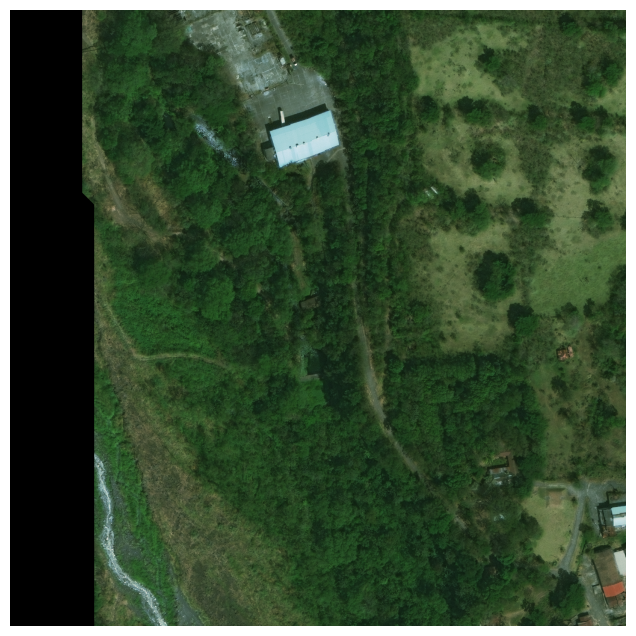

In [5]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np

with rasterio.open(ejemplo["pre_img"]) as src:

    print(src.count)

    img = src.read()

print(img.shape)

rgb = np.transpose(
    img,
    (1, 2, 0)
)

print(rgb.min())
print(rgb.max())

plt.figure(figsize=(8,8))
plt.imshow(rgb.astype(np.uint8))
plt.axis("off")
plt.show()

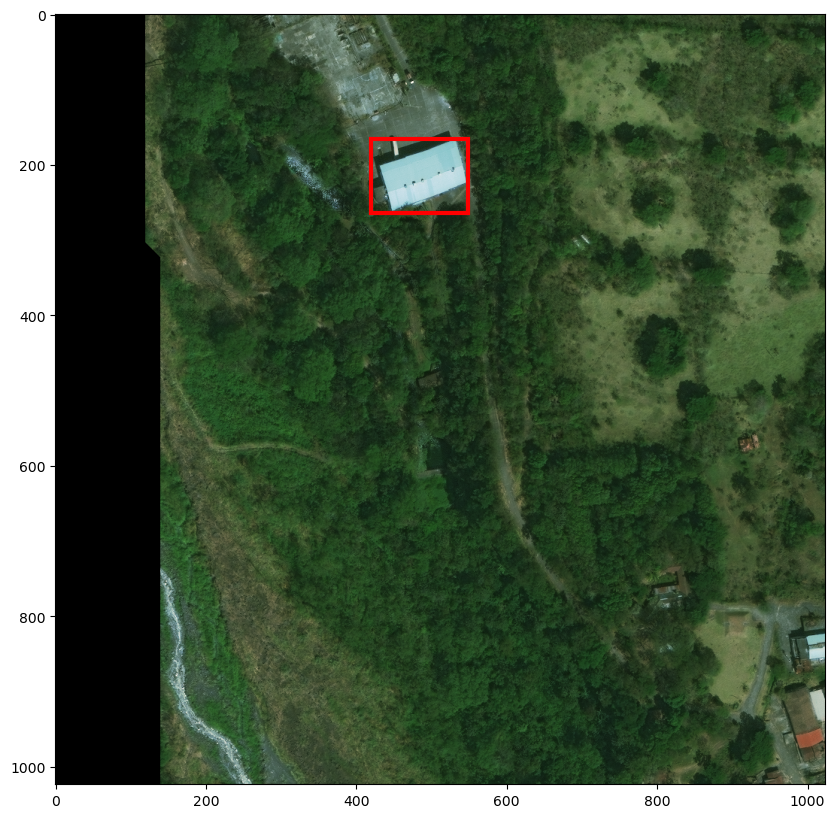

(1024, 1024, 3)
(420, 165, 548, 264)


In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

with rasterio.open(ejemplo["pre_img"]) as src:
    img = src.read()

img = np.transpose(img, (1, 2, 0))

fig, ax = plt.subplots(figsize=(10,10))

ax.imshow(img.astype(np.uint8))

xmin, ymin, xmax, ymax = bbox

rect = patches.Rectangle(
    (xmin, ymin),
    xmax - xmin,
    ymax - ymin,
    linewidth=3,
    edgecolor="red",
    facecolor="none"
)

ax.add_patch(rect)

plt.show()

print(img.shape)
print(bbox)


In [7]:
from src.dataset import XView2
from src.configuracion import DATASET_DIR

dataset = XView2(DATASET_DIR)

print(len(dataset))

Escenas encontradas: 11034
Total edificios: 411357
411357


In [8]:
pre_img, post_img, label = dataset[0]

print(pre_img.shape)
print(post_img.shape)
print(label)

torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
tensor(0)


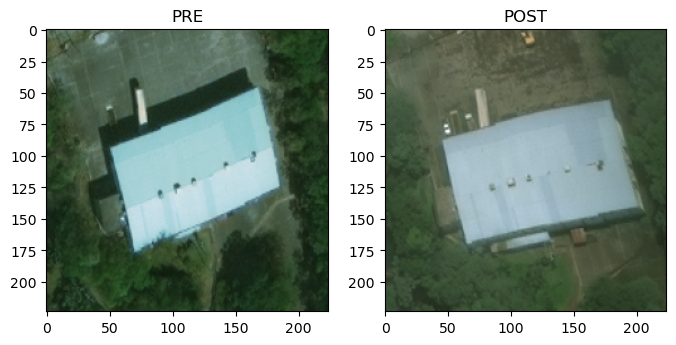

Label: 0


In [9]:
pre_img, post_img, label = dataset[0]

pre_vis = pre_img.permute(1, 2, 0).numpy()
post_vis = post_img.permute(1, 2, 0).numpy()

fig, ax = plt.subplots(1, 2, figsize=(8, 4))

ax[0].imshow(pre_vis)
ax[0].set_title("PRE")

ax[1].imshow(post_vis)
ax[1].set_title("POST")

plt.show()

print("Label:", label.item())

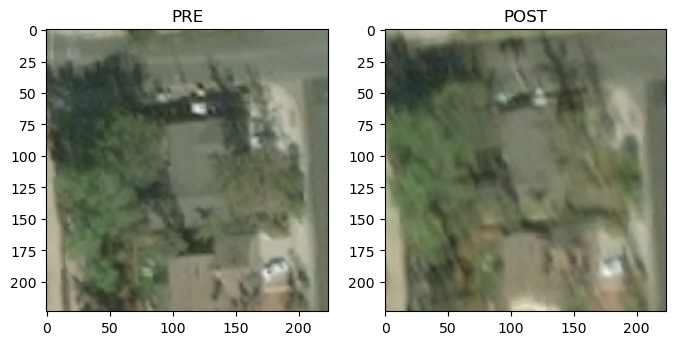

Label: 0
(360, 407, 412, 456)
Ancho: 52
Alto: 49


In [19]:
import random
import matplotlib.pyplot as plt

idx = random.randint(0, len(dataset)-1)

pre_img, post_img, label = dataset[idx]

pre_vis = pre_img.permute(1,2,0).numpy()
post_vis = post_img.permute(1,2,0).numpy()

fig, ax = plt.subplots(1,2,figsize=(8,4))

ax[0].imshow(pre_vis)
ax[0].set_title("PRE")

ax[1].imshow(post_vis)
ax[1].set_title("POST")

plt.show()

print("Label:", label.item())

xmin, ymin, xmax, ymax = dataset.samples[idx]["bbox"]

print(dataset.samples[idx]["bbox"])
print("Ancho:", xmax - xmin)
print("Alto:", ymax - ymin)